# Lezione 3 — Anomaly detection e manutenzione predittiva

**Modulo 3.** Corso di AI applicata, Zucchetti Centro Sistemi.

Il notebook si esegue dall'alto in basso. Non serve GPU e non serve installare niente:
girano solo pandas, scikit-learn e matplotlib, che su Colab ci sono già.

Tre celle sono marcate `PUNTO DI VARIAZIONE`: contengono una costante da cambiare
prima di rieseguire.

### Dati

**NASA C-MAPSS**, sottoinsieme **FD001**: cento motori turbofan simulati, ventuno
sensori, una sola condizione operativa e un solo modo di guasto.

> A. Saxena, K. Goebel, D. Simon, N. Eklund. *Damage Propagation Modeling for Aircraft
> Engine Run-to-Failure Simulation.* PHM08, Denver, ottobre 2008.

Fonte: NASA Prognostics Data Repository, mirror su
[Zenodo](https://zenodo.org/records/15346912). Dato governativo statunitense, non
soggetto a copyright; il deposito Zenodo lo dichiara
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

### Il filo

**In questi dati le anomalie non ci sono.** L'unica cosa registrata è quanti cicli
mancano al guasto. «Anomalia» non è un dato: è una decisione che prendiamo noi, e da
come la prendiamo dipende ogni numero che viene dopo.

In [1]:
# Dati e librerie. Su Colab la prima esecuzione impiega una ventina di secondi.
import io, zipfile, urllib.request, pathlib, warnings
warnings.filterwarnings("ignore")

D = pathlib.Path("dati")
if not (D / "train_FD001.txt").exists():
    with urllib.request.urlopen(
        "https://github.com/nunziati/zcs-ai-course-2026/releases/download/"
        "dati-cmapss/cmapss.zip") as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, f1_score, mean_absolute_error
from sklearn.model_selection import train_test_split
plt.rcParams["figure.dpi"] = 110
print("pronto, nessuna GPU richiesta")

pronto, nessuna GPU richiesta


---

# Passo 2 — Dati

In [2]:
# Ventisei colonne senza intestazione, separate da spazi.
COLONNE = ["unit", "ciclo", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
SENSORI = [f"s{i}" for i in range(1, 22)]

def carica(nome):
    d = pd.read_csv(D / nome, sep=r"\s+", header=None, names=COLONNE)
    # cicli residui: quanti ne mancano alla fine della traiettoria di quel motore.
    d["residui"] = d.groupby("unit").ciclo.transform("max") - d.ciclo
    return d

train = carica("train_FD001.txt")
durate = train.groupby("unit").ciclo.max()

print(f"{len(train)} righe, {train.unit.nunique()} motori")
print(f"durata: minima {durate.min()} cicli, mediana {durate.median():.0f}, massima {durate.max()}")
print(f"motori portati fino al guasto: {(train.groupby('unit').residui.min() == 0).sum()} su 100")
print("\nIn un impianto vero la maggior parte delle macchine è ancora in funzione, e il")
print("suo tempo al guasto non si è ancora osservato. Qui invece è finito tutto, e va")
print("tenuto a mente: è un dataset di simulazione, non un archivio di manutenzione.")
train[["unit", "ciclo", "s2", "s7", "s11", "s14", "residui"]].head(4)

20631 righe, 100 motori
durata: minima 128 cicli, mediana 199, massima 362
motori portati fino al guasto: 100 su 100

In un impianto vero la maggior parte delle macchine è ancora in funzione, e il
suo tempo al guasto non si è ancora osservato. Qui invece è finito tutto, e va
tenuto a mente: è un dataset di simulazione, non un archivio di manutenzione.


,unit,ciclo,s2,s7,s11,s14,residui
0,1,1,641.82,554.36,47.47,8138.62,191
1,1,2,642.15,553.75,47.49,8131.49,190
2,1,3,642.35,554.26,47.27,8133.23,189
3,1,4,642.35,554.45,47.13,8133.83,188


costanti, un solo valore in tutto il dataset: ['s1', 's5', 's10', 's16', 's18', 's19']
quasi costanti, al più cinque valori:          ['s6']
restano 14 sensori che si muovono: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


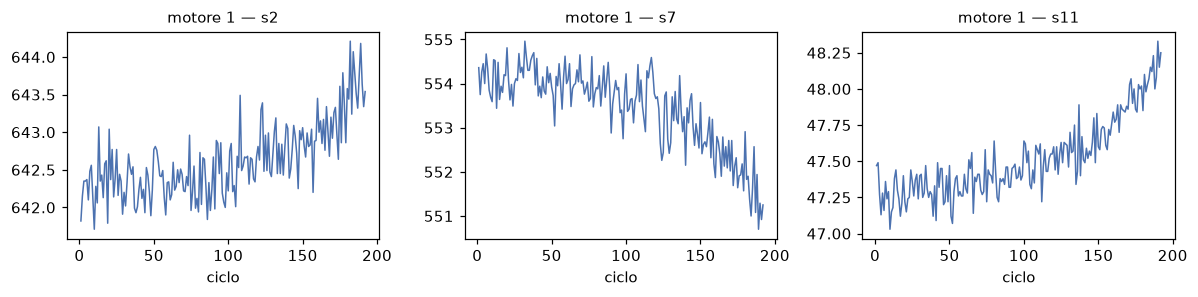

La deriva c'è, ma comincia tardi ed è sepolta nel rumore.


In [3]:
# Non tutti i sensori sono sensori.
costanti = [s for s in SENSORI if train[s].nunique() == 1]
pochi = [s for s in SENSORI if s not in costanti and train[s].nunique() <= 5]
UTILI = [s for s in SENSORI if s not in costanti and s not in pochi]

print(f"costanti, un solo valore in tutto il dataset: {costanti}")
print(f"quasi costanti, al più cinque valori:          {pochi}")
print(f"restano {len(UTILI)} sensori che si muovono: {UTILI}")

uno = train[train.unit == 1]
fig, assi = plt.subplots(1, 3, figsize=(11, 2.8))
for ax, s in zip(assi, ["s2", "s7", "s11"]):
    ax.plot(uno.ciclo, uno[s], lw=1, color="#4c72b0")
    ax.set_title(f"motore 1 — {s}", fontsize=10); ax.set_xlabel("ciclo")
plt.tight_layout(); plt.show()
print("La deriva c'è, ma comincia tardi ed è sepolta nel rumore.")

In [4]:
# Il punto di partenza della giornata: qui non c'è nessuna etichetta di anomalia.
# L'unica cosa registrata è quanti cicli mancano al guasto, ed è continua.
print("colonne disponibili:", [c for c in train.columns if c not in SENSORI])
print("\nQuanto dicono i sensori, per fascia di cicli residui")
print("(correlazione assoluta con i cicli residui, mediana sui 14 sensori utili):\n")
for lo, hi, etichetta in [(200, 10**9, "più di 200"), (100, 200, "da 100 a 200"),
                          (50, 100, "da 50 a 100"), (0, 50, "meno di 50")]:
    s = train[(train.residui > lo) & (train.residui <= hi)]
    c = np.nanmedian([abs(s[u].corr(s.residui)) for u in UTILI])
    print(f"  cicli residui {etichetta:14s} {len(s):6d} righe   correlazione {c:.3f}")

print("\nPer i primi due terzi di vita i sensori non dicono niente, e non perché siano")
print("rotti: il guasto non è ancora cominciato. Non c'è niente da prevedere, lì.")

colonne disponibili: ['unit', 'ciclo', 'op1', 'op2', 'op3', 'residui']

Quanto dicono i sensori, per fascia di cicli residui
(correlazione assoluta con i cicli residui, mediana sui 14 sensori utili):

  cicli residui più di 200       1958 righe   correlazione 0.027
  cicli residui da 100 a 200     8573 righe   correlazione 0.138
  cicli residui da 50 a 100      5000 righe   correlazione 0.248
  cicli residui meno di 50       5000 righe   correlazione 0.599

Per i primi due terzi di vita i sensori non dicono niente, e non perché siano
rotti: il guasto non è ancora cominciato. Non c'è niente da prevedere, lì.


---

# Passo 3 — Dalla baseline al metodo

In [5]:
# PUNTO DI VARIAZIONE
# Quanti cicli iniziali di ogni motore consideriamo "macchina nuova".
PRIMI_CICLI = 30

# Il profilo del normale: media e deviazione standard nei primi cicli. Nessuna
# etichetta usata, e nessuna informazione su quando il motore si romperà.
nuovo = train[train.ciclo <= PRIMI_CICLI]
media, scarto = nuovo[UTILI].mean(), nuovo[UTILI].std()

# Punteggio di anomalia: quanto lontano è il motore dal proprio profilo di partenza.
scostamento = (train[UTILI] - media) / scarto
train["punteggio"] = np.sqrt((scostamento ** 2).mean(axis=1))
train["liscio"] = train.groupby("unit").punteggio.transform(
    lambda s: s.rolling(20, min_periods=1).mean())

print(f"profilo costruito su {len(nuovo)} righe, i primi {PRIMI_CICLI} cicli di ogni motore")
print(f"punteggio medio a macchina nuova: {train.loc[nuovo.index, 'liscio'].mean():.3f}")

profilo costruito su 3000 righe, i primi 30 cicli di ogni motore
punteggio medio a macchina nuova: 0.972


punteggio medio per fascia di cicli residui:

  cicli residui più di 200       1958 righe   punteggio 0.94
  cicli residui da 100 a 200     8573 righe   punteggio 0.98


  cicli residui da 50 a 100      5000 righe   punteggio 1.20
  cicli residui da 20 a 50       3000 righe   punteggio 1.95
  cicli residui meno di 20       2000 righe   punteggio 3.08


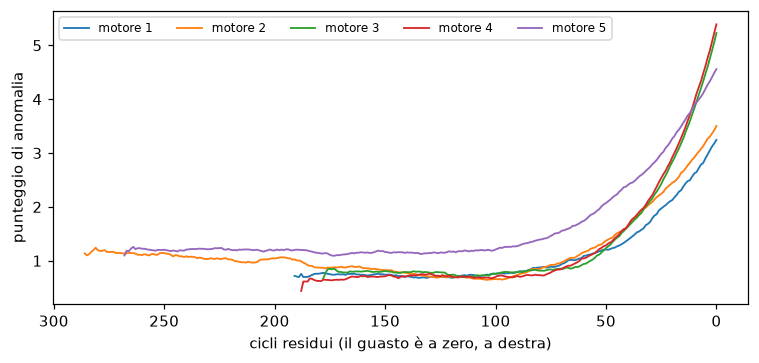

In [6]:
# Il punteggio sale, e sale quando serve.
print("punteggio medio per fascia di cicli residui:\n")
for lo, hi, etichetta in [(200, 10**9, "più di 200"), (100, 200, "da 100 a 200"),
                          (50, 100, "da 50 a 100"), (20, 50, "da 20 a 50"),
                          (0, 20, "meno di 20")]:
    s = train[(train.residui > lo) & (train.residui <= hi)]
    print(f"  cicli residui {etichetta:14s} {len(s):6d} righe   punteggio {s.liscio.mean():.2f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
for u in [1, 2, 3, 4, 5]:
    g = train[train.unit == u]
    ax.plot(g.residui, g.liscio, lw=1.2, label=f"motore {u}")
ax.invert_xaxis()
ax.set_xlabel("cicli residui (il guasto è a zero, a destra)")
ax.set_ylabel("punteggio di anomalia"); ax.legend(fontsize=8, ncol=5)
plt.tight_layout(); plt.show()

soglia = 99° percentile a macchina nuova = 1.385

motori su cui l'allarme scatta: 100 su 100
preavviso in cicli: mediana 58, minimo 23, massimo 282
  un motore su dieci ha meno di 30 cicli di preavviso
  6 motori suonano più di 150 cicli prima: allarmi prematuri


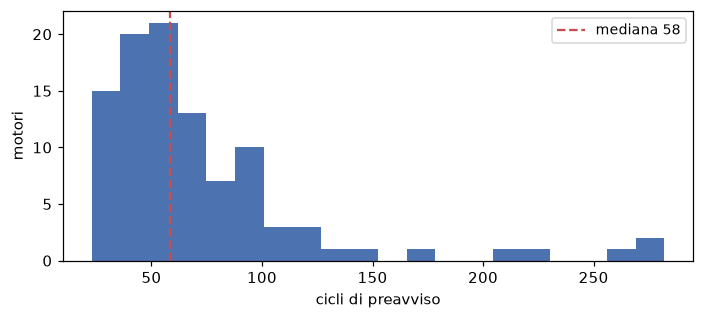

La cosa consegnata alla manutenzione è questo istogramma, non un F1.


In [7]:
# PUNTO DI VARIAZIONE
# Quanto in alto mettere la soglia, in percentile del punteggio a macchina nuova.
PERCENTILE_SOGLIA = 99

# La soglia si tara sul periodo normale, non sui guasti: in produzione i guasti
# non li hai ancora visti.
soglia = train[train.ciclo <= PRIMI_CICLI].liscio.quantile(PERCENTILE_SOGLIA / 100)
print(f"soglia = {PERCENTILE_SOGLIA}° percentile a macchina nuova = {soglia:.3f}\n")

preavviso = []
for u, g in train.groupby("unit"):
    sopra = g[g.liscio >= soglia]
    preavviso.append(sopra.residui.max() if len(sopra) else np.nan)
preavviso = pd.Series(preavviso, index=train.unit.unique())

scattati = preavviso.notna()
print(f"motori su cui l'allarme scatta: {scattati.sum()} su {len(preavviso)}")
p = preavviso.dropna()
print(f"preavviso in cicli: mediana {p.median():.0f}, minimo {p.min():.0f}, massimo {p.max():.0f}")
print(f"  un motore su dieci ha meno di {p.quantile(.10):.0f} cicli di preavviso")
print(f"  {(p > 150).sum()} motori suonano più di 150 cicli prima: allarmi prematuri")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(p, bins=20, color="#4c72b0")
ax.axvline(p.median(), color="#c44e52", ls="--", lw=1.5, label=f"mediana {p.median():.0f}")
ax.set_xlabel("cicli di preavviso"); ax.set_ylabel("motori"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("La cosa consegnata alla manutenzione è questo istogramma, non un F1.")

---

# Passo 4 — Valutazione

In [8]:
# PUNTO DI VARIAZIONE
# Da quanti cicli prima del guasto chiamiamo "anomalo" un ciclo.
SOGLIA_ANOMALIA = 30

train["anomalia"] = (train.residui <= SOGLIA_ANOMALIA).astype(int)
print(f"{'cicli prima del guasto':>24s} {'righe anomale':>14s} {'quota':>8s}")
for k in (10, 20, 30, 50, 100):
    q = (train.residui <= k)
    segno = "   <--" if k == SOGLIA_ANOMALIA else ""
    print(f"{k:>24d} {q.sum():>14d} {q.mean():>8.1%}{segno}")

print("\nNon esiste la soglia giusta: esiste quella che corrisponde al preavviso che la")
print("manutenzione riesce a usare. Cambiandola cambia il problema, non solo il numero.")

  cicli prima del guasto  righe anomale    quota
                      10           1100     5.3%
                      20           2100    10.2%
                      30           3100    15.0%   <--
                      50           5100    24.7%
                     100          10100    49.0%

Non esiste la soglia giusta: esiste quella che corrisponde al preavviso che la
manutenzione riesce a usare. Cambiandola cambia il problema, non solo il numero.


In [9]:
# Prima trappola: come si divide train e test.
def medie_mobili(d, finestra):
    if finestra == 1:
        return d[UTILI].copy()
    return d.groupby("unit")[UTILI].transform(
        lambda s: s.rolling(finestra, min_periods=1).mean())

y = train.anomalia.values
rng = np.random.default_rng(0)
motori = train.unit.unique().copy(); rng.shuffle(motori)
in_train = train.unit.isin(set(motori[:70])).values

print(f"{'finestra':>10s} {'split casuale':>15s} {'split per motore':>18s} {'errori':>18s}")
for finestra in (1, 10, 30):
    X = medie_mobili(train, finestra)
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=.3, random_state=0, stratify=y)
    a = RandomForestClassifier(n_estimators=80, random_state=0, n_jobs=-1).fit(Xa, ya)
    auc_a = roc_auc_score(yb, a.predict_proba(Xb)[:, 1])
    b = RandomForestClassifier(n_estimators=80, random_state=0, n_jobs=-1).fit(X[in_train], y[in_train])
    auc_b = roc_auc_score(y[~in_train], b.predict_proba(X[~in_train])[:, 1])
    print(f"{finestra:>7d} ci {auc_a:>15.4f} {auc_b:>18.4f} "
          f"{(1 - auc_b) / (1 - auc_a):>15.1f} volte")

print("\nCon i valori grezzi le due colonne quasi coincidono. Man mano che si smussa —")
print("e su questi sensori si smussa sempre — righe consecutive condividono gran parte")
print("della finestra, quindi una finisce in train e la sua quasi gemella in test.")
print("Lo split casuale misura la memoria. I motori vanno tenuti interi da una parte sola.")

  finestra   split casuale   split per motore             errori


      1 ci          0.9889             0.9867             1.2 volte


     10 ci          0.9972             0.9838             5.9 volte


     30 ci          0.9972             0.9644            12.9 volte

Con i valori grezzi le due colonne quasi coincidono. Man mano che si smussa —
e su questi sensori si smussa sempre — righe consecutive condividono gran parte
della finestra, quindi una finisce in train e la sua quasi gemella in test.
Lo split casuale misura la memoria. I motori vanno tenuti interi da una parte sola.


In [10]:
# Seconda trappola: il protocollo con cui è stata pubblicata metà della letteratura.
def point_adjust(vero, predetto):
    """Se il rilevatore becca UN punto dentro un guasto, gli si regalano tutti gli altri."""
    p = predetto.copy()
    dentro, inizio = False, 0
    for i, v in enumerate(vero):
        if v and not dentro:
            dentro, inizio = True, i
        elif not v and dentro:
            if p[inizio:i].any(): p[inizio:i] = 1
            dentro = False
    if dentro and p[inizio:].any(): p[inizio:] = 1
    return p

ordinato = train.sort_values(["unit", "ciclo"])
vero = ordinato.anomalia.values

print(f"{'segnala a caso':>16s} {'F1 grezzo':>11s} {'F1 point-adjusted':>19s}")
for quota in (0.01, 0.05, 0.10):
    caso = (np.random.default_rng(1).random(len(vero)) < quota).astype(int)
    print(f"{quota:>15.0%} {f1_score(vero, caso):>11.3f} "
          f"{f1_score(vero, point_adjust(vero, caso)):>19.3f}")

print("\nUn punteggio completamente casuale, che non guarda nemmeno i dati, passa da")
print("0,08 a 0,78 di F1 solo cambiando il modo di contare. Quando un articolo riporta")
print("un F1 alto su serie temporali, la prima domanda è con quale protocollo.")
print("\nKim et al., Towards a rigorous evaluation of time-series anomaly detection, AAAI 2022.")

  segnala a caso   F1 grezzo   F1 point-adjusted
             1%       0.018               0.384
             5%       0.077               0.777
            10%       0.113               0.735

Un punteggio completamente casuale, che non guarda nemmeno i dati, passa da
0,08 a 0,78 di F1 solo cambiando il modo di contare. Quando un articolo riporta
un F1 alto su serie temporali, la prima domanda è con quale protocollo.

Kim et al., Towards a rigorous evaluation of time-series anomaly detection, AAAI 2022.


In [11]:
# E se invece di dire "anomalo sì o no" provassimo a prevedere quanti cicli mancano?
def finestra_20(d):
    return d.groupby("unit")[UTILI].transform(lambda s: s.rolling(20, min_periods=1).mean())

test = carica("test_FD001.txt")
residui_veri = pd.read_csv(D / "RUL_FD001.txt", header=None).iloc[:, 0].values
X_train_r = finestra_20(train)
X_test_r = finestra_20(test).loc[test.groupby("unit").tail(1).index]

for taglio in (None, 125):
    bersaglio = train.residui.values.astype(float)
    if taglio:
        bersaglio = np.minimum(bersaglio, taglio)
    m = RandomForestRegressor(n_estimators=80, random_state=0, n_jobs=-1)
    m.fit(X_train_r[in_train], bersaglio[in_train])
    stima = m.predict(X_test_r)
    atteso = np.minimum(residui_veri, taglio) if taglio else residui_veri
    vicini = residui_veri <= 50
    nome = f"bersaglio tagliato a {taglio}" if taglio else "bersaglio grezzo"
    print(f"{nome:24s} errore medio {mean_absolute_error(atteso, stima):5.1f} cicli"
          f"   | vicini al guasto {mean_absolute_error(atteso[vicini], stima[vicini]):5.1f}"
          f"   | lontani {mean_absolute_error(atteso[~vicini], stima[~vicini]):5.1f}")

print("\nTagliare il bersaglio migliora l'errore di sette cicli, e il guadagno sta tutto")
print("sui motori lontani dal guasto: sui vicini non cambia niente. Non è un trucco: è")
print("la stessa cosa vista nel Passo 2, scritta stavolta dentro il bersaglio. Se per i")
print("primi due terzi di vita non c'è segnale, chiedere al modello di distinguere 300")
print("cicli residui da 250 è chiedergli di indovinare.")

bersaglio grezzo         errore medio  23.8 cicli   | vicini al guasto  15.6   | lontani  27.9


bersaglio tagliato a 125 errore medio  16.5 cicli   | vicini al guasto  15.3   | lontani  17.0

Tagliare il bersaglio migliora l'errore di sette cicli, e il guadagno sta tutto
sui motori lontani dal guasto: sui vicini non cambia niente. Non è un trucco: è
la stessa cosa vista nel Passo 2, scritta stavolta dentro il bersaglio. Se per i
primi due terzi di vita non c'è segnale, chiedere al modello di distinguere 300
cicli residui da 250 è chiedergli di indovinare.


---

## Cosa resta

**L'etichetta non c'era.** In questo dataset è registrato solo quanto manca al guasto.
«Anomalo» l'abbiamo definito noi con una costante, e cambiando quella costante cambia
la quota di positivi, cambia il modello e cambia ogni metrica che viene dopo.

**Si può rilevare senza etichette.** Bastano i primi cicli di ogni macchina come
profilo del normale e una distanza. La soglia si tara sul periodo normale, perché in
produzione i guasti non li hai ancora visti. Il risultato consegnato è **quanti cicli
di preavviso**, mediana 58 su questi motori, e un motore su dieci ne dà meno di trenta.

**Due modi di ottenere numeri ottimi che non vogliono dire niente.** Dividere train e
test per riga invece che per macchina, che con le medie mobili moltiplica gli errori
per dieci. E contare con il point adjustment, che porta un punteggio casuale da 0,08 a
0,78 di F1.

**Il segnale non c'è ovunque.** Per i primi due terzi di vita i sensori non si muovono,
e questo si vede due volte: nella correlazione per fascia, e nel fatto che tagliare il
bersaglio della regressione migliora l'errore solo sui motori lontani dal guasto.